# MAP and Laplace Approximation: Electrical Impedance Tomography

- PDE: $-\nabla \cdot (a \nabla u) = 0$
- Latent dimension: $d_a = 6$ (normalising flow and MCMC dimension), $d_u = 26$ (with boundary encoding)
- Observations: Neumann boundary flux at 124 boundary points

In [1]:
import sys, itertools
sys.path.insert(0, 'experiment_utils')
from _slurm import parse_slurm_task

PARAMETER_GRID = [
    {"seed": s, "test_idx": t}
    for s, t in itertools.product([42, 123, 7], [0, 1, 2])
]
_params, _task_id = parse_slurm_task(PARAMETER_GRID)

In [2]:
sys.path.insert(0, '..')
import load_this_before_everything_else

import jax
import jax.numpy as jnp
from jax import random
import numpy as np
import time
from pathlib import Path
from datetime import datetime

from src.problems.eit import EIT, one_hot_g_l, mollifier_eit
from src.evaluation.metrics import rmse
from src.evaluation.laplace import compute_hessian, sample_laplace
from src.solver.config import InversionConfig, LossWeights, OptimizerConfig, SchedulerConfig

from experiment_utils import (
    crps_ensemble, compute_calibration, ci_width_95, nll_score,
    compute_error_std_correlation,
    plot_eit_ground_truth, plot_eit_observation_data,
    build_laplace_result, save_experiment_result,
    load_problem, run_map_estimation, make_igno_loss_fn,
    print_cross_seed_summary,
)
from results_schema import ExperimentResult

SEEDS = [42, 123, 7]
if _task_id is not None:
    SEEDS = [PARAMETER_GRID[_task_id]["seed"]]

print(f"JAX: {jax.__version__}")
print(f"Devices: {jax.devices()}")

HIGH PRECISION MODE ACTIVATED!!!


JAX: 0.4.35


Devices: [CudaDevice(id=0)]


## 1. Load Trained Model

In [3]:
CHECKPOINT_PATH = Path("../runs/final_eit/weights/best.pt")
TEST_DATA_PATH = "../data/eit/inverse_EIT_in.mat"

problem = EIT(seed=42, test_data_path=TEST_DATA_PATH)
params = load_problem(problem, CHECKPOINT_PATH)

print(f"Latent dim (coeff): {problem.BETA_SIZE_A}")
print(f"Latent dim (combined): {problem.BETA_SIZE_U}")

Loading data...


  Test: a=(20, 1024, 1), u=[[[ 1.        ]
  [ 0.9797001 ]
  [ 0.9204757 ]
  ...
  [ 0.8746724 ]
  [ 0.761118  ]
  [ 0.6172527 ]]

 [[ 1.        ]
  [ 0.981173  ]
  [ 0.9261911 ]
  ...
  [ 0.3165446 ]
  [ 0.12906456]
  [-0.06325148]]

 [[ 1.        ]
  [ 0.98346853]
  [ 0.9351161 ]
  ...
  [-0.2334332 ]
  [-0.40426344]
  [-0.5620679 ]]

 ...

 [[ 1.        ]
  [ 0.981173  ]
  [ 0.9261911 ]
  ...
  [-0.8738502 ]
  [-0.7647962 ]
  [-0.62749803]]

 [[ 1.        ]
  [ 0.9797001 ]
  [ 0.9204757 ]
  ...
  [ 0.10988297]
  [ 0.30528814]
  [ 0.48864248]]

 [[ 1.        ]
  [ 0.9791928 ]
  [ 0.918509  ]
  ...
  [ 0.918509  ]
  [ 0.9791928 ]
  [ 1.        ]]]
  Boundary points: 124 (left=32, top=31, right=31, bottom=30)
Setting up grids and test functions...


  int_grid: (25, 2), v: (25, 1)
Building models...


  Initialized enc: 113,702 params


  Initialized u: 83,805 params


  Initialized a: 81,805 params


E0612 05:25:20.655286      23 hlo_lexer.cc:443] Failed to parse int literal: 894515288310727292233


  Initialized nf: 15,420 params
Loading checkpoint: ../runs/final_eit/weights/best.pt
  Loaded enc
  Loaded u
  Loaded a
  Loaded nf
Latent dim (coeff): 6
Latent dim (combined): 26


## 2. Prepare Observations

In [4]:
TEST_IDX = 0
if _task_id is not None:
    TEST_IDX = PARAMETER_GRID[_task_id]["test_idx"]
N_OBS = 124

n_points = problem.get_n_points()

## 3. Inversion Config

In [5]:
inv_config = InversionConfig(
    epochs=1000,
    loss_weights=LossWeights(pde=1.0, data=100.0),
    optimizer=OptimizerConfig(type='Adam', lr=0.01),
    scheduler=SchedulerConfig(type='StepLR', step_size=125, gamma=0.25),
)

## 4. Per-Seed Loop


SEED = 42


x_obs (boundary): (1, 124, 2), u_obs (Neumann flux): (1, 124, 1)
Boundary points: 124, g_l = 2


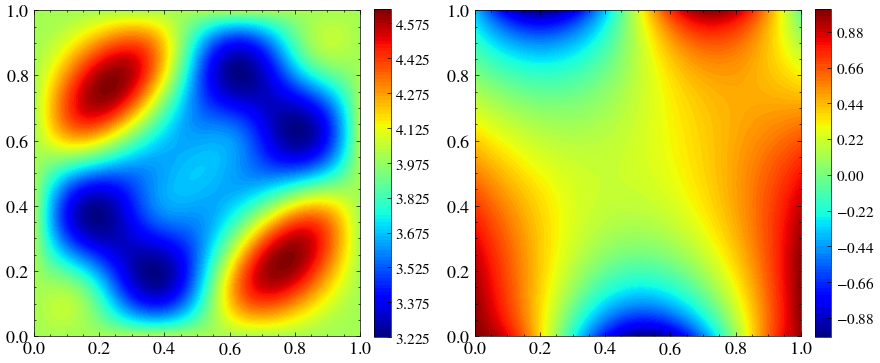

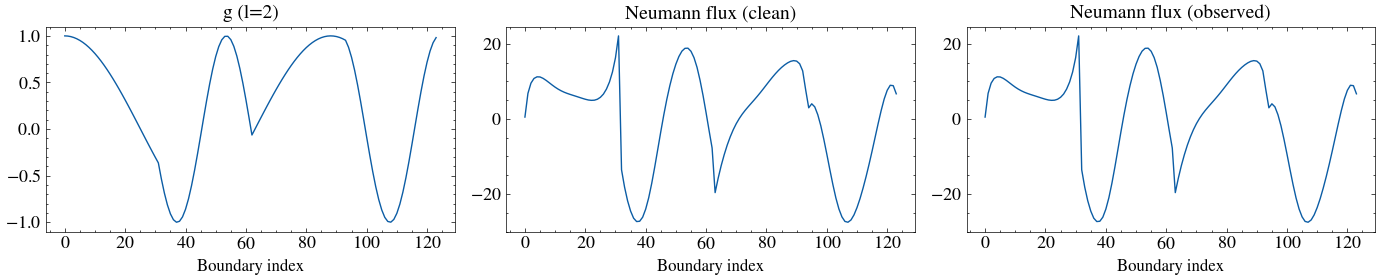

  Inversion grid: n_mesh_or_grid=7, n_grid=25


Loss weights: pde=1.0, data=100.0, target=neumann


Inverting:   0%|          | 0/1000 [00:00<?, ?it/s]

Inverting:   0%|          | 1/1000 [00:04<1:11:15,  4.28s/it]

Inverting:   8%|▊         | 80/1000 [00:04<00:35, 25.74it/s] 

...

Final: loss_pde=1.009923, loss_data=0.005954
MAP completed in 14.2s



MAP RMSE (a): 0.005996


  Laplace: frac_clipped=0.0000, hessian_time=5.6s


  Laplace metrics: a_err=0.008514, crps_a=0.034519, cov95=1.0000, ci_w=0.568046, sharpness=0.144402


Saved structured result to: /workspace/experiments/results/structured/map_laplace/eit_2026-06-12T05-25-59_seed42_test1.json


In [6]:
NUM_SAMPLES = 2000
NUM_CHAINS = 4

for SEED in SEEDS:
    print(f"\n{'='*60}")
    print(f"SEED = {SEED}")
    print(f"{'='*60}")

    FIGURE_DIR = Path(f'figures/map_laplace_eit/seed_{SEED}')
    FIGURE_DIR.mkdir(parents=True, exist_ok=True)

    # ### Observations (this seed)

    rng = random.PRNGKey(SEED)
    rng, key = random.split(rng)

    obs_indices = problem.sample_observation_indices(n_points, N_OBS, 'random', key)

    obs_data = problem.prepare_observations(
        sample_indices=[TEST_IDX],
        obs_indices=obs_indices,
    )

    x_full = obs_data['x_full']
    x_obs = obs_data['x_obs']
    u_obs = obs_data['u_obs']
    a_true = obs_data['a_true']
    g_l = obs_data['g_l']
    u_true = obs_data.get('u_true', None)

    print(f"x_obs (boundary): {x_obs.shape}, u_obs (Neumann flux): {u_obs.shape}")
    print(f"Boundary points: {x_obs.shape[1]}, g_l = {int(g_l[0, 0])}")

    # ### Ground truth and observation plots

    plot_eit_ground_truth(
        np.array(x_full[0]),
        np.array(a_true[0, :, 0]),
        u_true=np.array(u_true[0, :, 0]) if u_true is not None else None,
        save_path=FIGURE_DIR / 'ground_truth.png',
    )

    plot_eit_observation_data(
        x_bd=np.array(x_obs[0]),
        g_l=int(g_l[0, 0]),
        neumann_obs=np.array(u_obs[0, :, 0]),
        save_path=FIGURE_DIR / 'observation_data.png',
    )

    # ### MAP Baseline

    map_result = run_map_estimation(problem, params, x_obs, u_obs, x_full, inv_config, rng)
    beta_map = map_result['beta_map']
    a_map = map_result['a_map']
    rng = map_result['rng']

    rmse_map_a = rmse(a_map, a_true[0])
    print(f"\nMAP RMSE (a): {rmse_map_a:.6f}")

    from src.utils.PlotFigure import Plot
    h = map_result['loss_history']
    Plot.show_loss(
        [h['total'], h['weighted_pde'], h['weighted_data']],
        ['Total', f'PDE (×{inv_config.loss_weights.pde})', f'Data (×{inv_config.loss_weights.data})'],
        save_path=str(FIGURE_DIR / 'map_loss_curves.png'),
    )

    # ### Laplace Approximation (Hessian of IGNO objective at IGNO MAP)

    rng, hess_key = random.split(rng)
    igno_loss_fn = make_igno_loss_fn(problem, params, inv_config, x_obs, u_obs, hess_key)

    LA_N_SAMPLES = NUM_SAMPLES * NUM_CHAINS
    LA_REG_LAMBDA = 1e-4

    H, h_diag = compute_hessian(igno_loss_fn, beta_map[0], reg_lambda=LA_REG_LAMBDA)

    rng, la_key = random.split(rng)
    t0 = time.time()
    la_samples, frac_clip = sample_laplace(beta_map[0], H, LA_N_SAMPLES, la_key)
    sampling_time = time.time() - t0

    grad_fn = jax.grad(igno_loss_fn)
    grad_at_map = grad_fn(beta_map[0])
    grad_norm = float(jnp.linalg.norm(grad_at_map))

    print(f"  Laplace: frac_clipped={frac_clip:.4f}, "
          f"hessian_time={h_diag['hessian_time_s']:.1f}s")

    # Decode Laplace samples (EIT-specific: one-hot g_l concatenation + mollifier)
    beta_la = la_samples
    x_la = jnp.tile(x_full, (LA_N_SAMPLES, 1, 1))

    la_a_pred = problem.models['a'].apply({'params': params['a']}, x_la, beta_la)
    la_a_pred = la_a_pred[..., None] if la_a_pred.ndim == 2 else la_a_pred

    la_g_l_onehot = one_hot_g_l(problem._current_g_l)
    la_g_l_tiled = jnp.tile(la_g_l_onehot, (LA_N_SAMPLES, 1))
    la_beta_u = jnp.concatenate([beta_la, la_g_l_tiled], axis=-1)

    la_u_pred = problem.models['u'].apply({'params': params['u']}, x_la, la_beta_u)
    if la_u_pred.ndim == 2:
        la_u_pred = la_u_pred[..., None]
    la_g_l_for_moll = jnp.tile(problem._current_g_l, (LA_N_SAMPLES, 1))
    la_u_pred = mollifier_eit(la_u_pred.squeeze(-1), x_la, la_g_l_for_moll)

    la_a_true_np = np.array(a_true[0, :, 0])
    la_a_samples_np = np.array(la_a_pred[:, :, 0])
    la_a_mean_np = np.mean(la_a_samples_np, axis=0)
    la_a_std_np = np.std(la_a_samples_np, axis=0)

    la_rmse_a = rmse(jnp.array(la_a_mean_np), jnp.array(la_a_true_np))
    la_crps_a = float(np.mean(crps_ensemble(la_a_samples_np, la_a_true_np)))
    la_nll_a = nll_score(la_a_samples_np, la_a_true_np)
    la_cal_levels, la_cal_empirical = compute_calibration(la_a_samples_np, la_a_true_np)
    la_ci_w = ci_width_95(la_a_samples_np)
    la_sharpness = float(np.mean(la_a_std_np))
    if u_true is not None:
        la_u_true_np = np.array(u_true[0, :, 0])
        la_u_samples_np = np.array(la_u_pred)
        la_u_mean_np = np.mean(la_u_samples_np, axis=0)
        la_rmse_u = rmse(jnp.array(la_u_mean_np), jnp.array(la_u_true_np))
    else:
        la_rmse_u = 0.0

    if u_true is not None:
        u_map = map_result['u_map']
        map_u_err = float(rmse(u_map, u_true[0]))
    else:
        map_u_err = 0.0

    la_sp_rho, la_sp_p = compute_error_std_correlation(la_a_true_np, la_a_mean_np, la_a_std_np)

    print(f"  Laplace metrics: a_err={la_rmse_a:.6f}, "
          f"crps_a={la_crps_a:.6f}, cov95={float(la_cal_empirical[-1]):.4f}, "
          f"ci_w={la_ci_w:.6f}, sharpness={la_sharpness:.6f}")

    # ### Save Structured Result

    la_run_result = {
        "n_samples": LA_N_SAMPLES, "map_max_iter": 1000,
        "hessian_reg_lambda": LA_REG_LAMBDA,
        "neg_log_posterior_at_map": float(igno_loss_fn(beta_map[0])),
        "grad_norm_at_map": grad_norm,
        "map_converged": True,
        "hessian_min_eigenvalue": h_diag['min_eigenvalue_raw'],
        "hessian_condition_number": h_diag['condition_number'],
        "n_negative_eigenvalues": h_diag['n_negative_eigenvalues'],
        "fraction_clipped": frac_clip,
        "a_err": la_rmse_a, "u_err": float(la_rmse_u),
        "crps_a": la_crps_a, "nll_a": la_nll_a,
        "coverage_95": float(la_cal_empirical[-1]),
        "ci_width": float(la_ci_w), "mean_std": la_sharpness,
        "cal_levels": la_cal_levels, "cal_empirical": la_cal_empirical,
        "map_a_err": float(rmse_map_a),
        "map_u_err": map_u_err,
        "spearman_rho_error_std": la_sp_rho, "spearman_pvalue_error_std": la_sp_p,
        "map_time_s": map_result['time_s'], "hessian_time_s": h_diag['hessian_time_s'],
        "sampling_time_s": sampling_time,
    }
    la_result_obj = build_laplace_result(la_run_result)

    experiment = ExperimentResult(
        experiment="map_laplace",
        problem="eit",
        experiment_type="single",
        timestamp=datetime.now().strftime("%Y-%m-%dT%H:%M:%S"),
        seed=SEED,
        test_idx=TEST_IDX,
        condition=None,
        prior=None,
        laplace=la_result_obj,
    )

    out_path = save_experiment_result(experiment)
    print(f"Saved structured result to: {out_path}")

## Cross-Seed Aggregation Summary

In [7]:
print_cross_seed_summary("map_laplace", "eit")

Cross-Seed Summary (11 seeds: [7, 7, 7, 42, 42, 42, 42, 42, 123, 123, 123])

Metric                  Mean         Std         Min         Max
--------------------------------------------------------------
a_err                    nan         nan         nan         nan
u_err                    nan         nan         nan         nan
crps_a                   nan         nan         nan         nan
coverage_95              nan         nan         nan         nan
ci_width                 nan         nan         nan         nan
mean_std                 nan         nan         nan         nan
ess_min                  nan         nan         nan         nan
rhat_max                 nan         nan         nan         nan
n_div                    nan         nan         nan         nan
